In [1]:
from pathlib import Path
import sys
import time
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.deep_learning.cnn_dataset as cnn_dataset
import src.deep_learning.cnn_model as cnn_model

In [2]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print()

print("Device :", device)


Device : cpu


In [3]:
DATA = PROJECT_ROOT / "data" / "processed"

X_test = np.load(

    DATA / "cnn_X_test.npy"

)

y_test = np.load(

    DATA / "cnn_y_test.npy"

)

snr_test = np.load(

    DATA / "cnn_snr_test.npy"

)

label_encoder = joblib.load(

    DATA / "cnn_label_encoder.pkl"

)

print()

print("Testing Samples :", len(X_test))


Testing Samples : 9000


In [4]:
test_dataset = cnn_dataset.RadioMLDataset(

    X_test,

    y_test

)

test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=0
)

In [5]:
MODEL_DIR = PROJECT_ROOT / "models"

model = cnn_model.CNNModel(

    num_classes=9

)

checkpoint = torch.load(

    MODEL_DIR / "cnn_best.pth",

    map_location=device

)

model.load_state_dict(

    checkpoint["model_state_dict"]

)

model.to(device)

model.eval()

print()

print("CNN Loaded Successfully")


CNN Loaded Successfully


In [6]:
predictions = []

probabilities = []

ground_truth = []

start = time.time()

with torch.no_grad():

    for signals, labels in test_loader:

        signals = signals.to(device)

        outputs = model(signals)

        prob = torch.softmax(

            outputs,

            dim=1

        )

        prediction = outputs.argmax(1)

        predictions.extend(

            prediction.cpu().numpy()

        )

        probabilities.extend(

            prob.cpu().numpy()

        )

        ground_truth.extend(

            labels.numpy()

        )

prediction_time = time.time() - start

predictions = np.array(predictions)

probabilities = np.array(probabilities)

ground_truth = np.array(ground_truth)

print()

print("Prediction Completed")


Prediction Completed


In [7]:
per_sample = prediction_time / len(test_dataset)

print("="*60)

print("Prediction Time :", prediction_time)

print()

print("Inference Time per Sample :")

print(f"{per_sample*1000:.4f} ms")

print("="*60)

Prediction Time : 35.94913697242737

Inference Time per Sample :
3.9943 ms


In [8]:
accuracy = accuracy_score(

    ground_truth,

    predictions

)

precision = precision_score(

    ground_truth,

    predictions,

    average="weighted"

)

recall = recall_score(

    ground_truth,

    predictions,

    average="weighted"

)

f1 = f1_score(

    ground_truth,

    predictions,

    average="weighted"

)

print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print("="*60)

Accuracy  : 0.9916
Precision : 0.9917
Recall    : 0.9916
F1 Score  : 0.9916


In [9]:
report = classification_report(

    ground_truth,

    predictions,

    target_names=label_encoder.classes_

)

print(report)

              precision    recall  f1-score   support

        8PSK       0.99      0.97      0.98      1000
      AM-DSB       1.00      1.00      1.00      1000
      AM-SSB       0.96      1.00      0.98      1000
        BPSK       1.00      0.99      0.99      1000
       CPFSK       1.00      1.00      1.00      1000
        GFSK       1.00      1.00      1.00      1000
        PAM4       1.00      0.99      1.00      1000
       QAM64       0.99      0.99      0.99      1000
        QPSK       0.99      0.98      0.98      1000

    accuracy                           0.99      9000
   macro avg       0.99      0.99      0.99      9000
weighted avg       0.99      0.99      0.99      9000



In [10]:
cnn_results = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1 Score": f1,

    "Prediction Time": prediction_time,

    "Inference Time": per_sample

}

cnn_results

{'Accuracy': 0.9915555555555555,
 'Precision': 0.9917091351388618,
 'Recall': 0.9915555555555555,
 'F1 Score': 0.9915733148118986,
 'Prediction Time': 35.94913697242737,
 'Inference Time': 0.00399434855249193}

In [11]:
cm = confusion_matrix(
    ground_truth,
    predictions
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

,8PSK,AM-DSB,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM64,QPSK
8PSK,974,0,10,0,1,1,0,4,10
AM-DSB,0,999,0,0,0,1,0,0,0
AM-SSB,0,0,1000,0,0,0,0,0,0
BPSK,0,0,10,989,0,0,1,0,0
CPFSK,0,0,0,0,1000,0,0,0,0
GFSK,0,0,0,0,0,1000,0,0,0
PAM4,0,0,5,1,0,0,994,0,0
QAM64,2,0,8,0,0,0,2,987,1
QPSK,9,0,9,0,0,0,0,1,981


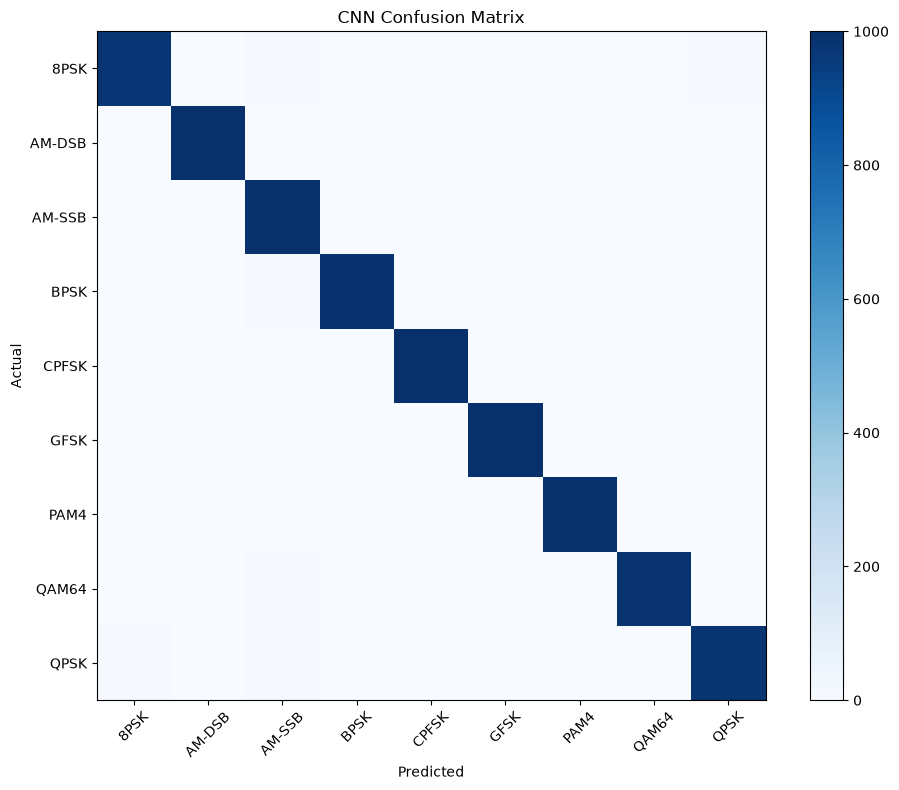

In [12]:
plt.figure(figsize=(10,8))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CNN Confusion Matrix")

plt.tight_layout()

plt.show()

In [13]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({

    "Modulation": label_encoder.classes_,

    "Accuracy": per_class_accuracy

})

per_class_df

,Modulation,Accuracy
0,8PSK,0.974
1,AM-DSB,0.999
2,AM-SSB,1.000
3,BPSK,0.989
4,CPFSK,1.000
5,GFSK,1.000
6,PAM4,0.994
7,QAM64,0.987
8,QPSK,0.981


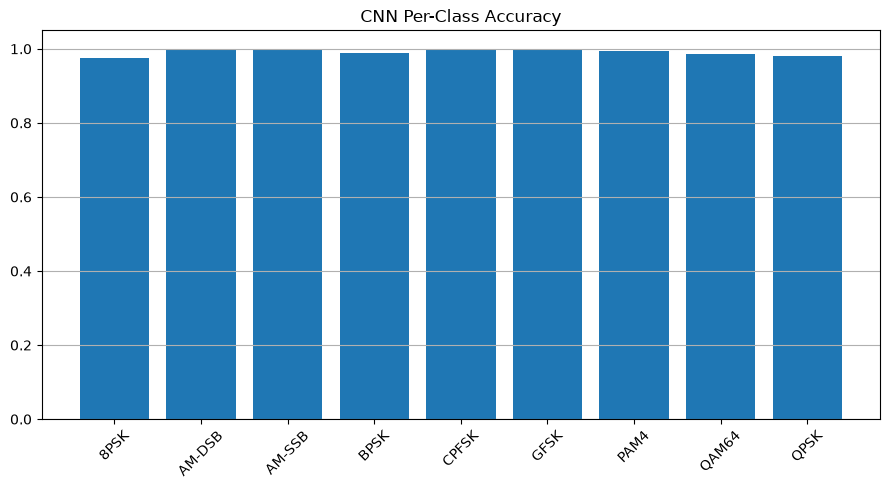

In [14]:
plt.figure(figsize=(9,5))

plt.bar(
    per_class_df["Modulation"],
    per_class_df["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylim(0,1.05)

plt.grid(axis="y")

plt.title("CNN Per-Class Accuracy")

plt.tight_layout()

plt.show()

In [15]:
snr_results = pd.DataFrame({

    "Actual": ground_truth,

    "Prediction": predictions,

    "SNR": snr_test

})

snr_accuracy = snr_results.groupby("SNR").apply(

    lambda x: (x.Actual == x.Prediction).mean()

)

snr_accuracy = snr_accuracy.reset_index(name="Accuracy")

snr_accuracy

,SNR,Accuracy
0,0,0.975890
1,2,0.993151
2,4,0.995455
3,6,0.995392
4,8,0.992081
5,10,0.995449
6,12,0.993776
7,14,0.988397
8,16,0.992222
9,18,0.993548


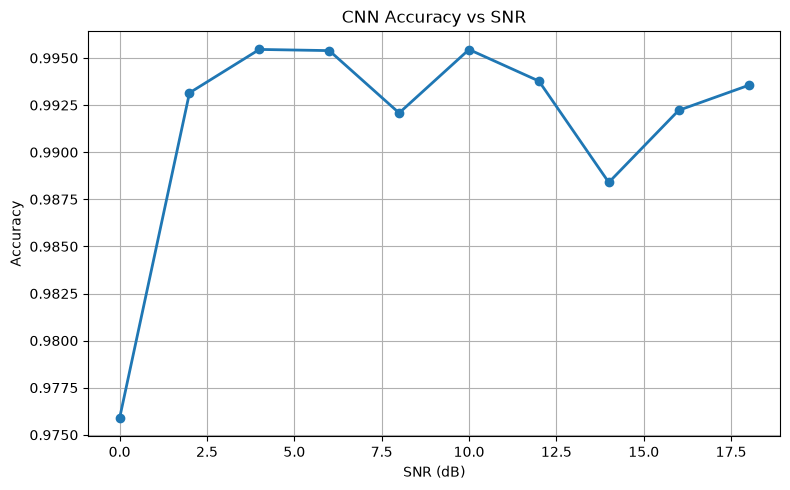

In [16]:
plt.figure(figsize=(8,5))

plt.plot(

    snr_accuracy["SNR"],

    snr_accuracy["Accuracy"],

    marker="o",

    linewidth=2

)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("CNN Accuracy vs SNR")

plt.tight_layout()

plt.show()

In [17]:
UNKNOWN_THRESHOLD = 0.75

unknown_predictions = []

for prob in probabilities:

    confidence = np.max(prob)

    prediction = np.argmax(prob)

    if confidence < UNKNOWN_THRESHOLD:

        unknown_predictions.append("Unknown")

    else:

        unknown_predictions.append(

            label_encoder.inverse_transform([prediction])[0]

        )

print()

print("Threshold :", UNKNOWN_THRESHOLD)

print()

print("Unknown Signals :",

      unknown_predictions.count("Unknown"))


Threshold : 0.75

Unknown Signals : 40


In [18]:
REPORT_DIR = PROJECT_ROOT / "results" / "reports"

REPORT_DIR.mkdir(

    parents=True,

    exist_ok=True

)

In [19]:
with open(

    REPORT_DIR / "cnn_classification_report.txt",

    "w"

) as file:

    file.write(report)

In [20]:
cm_df.to_csv(

    REPORT_DIR / "cnn_confusion_matrix.csv"

)

In [21]:
per_class_df.to_csv(

    REPORT_DIR / "cnn_per_class_accuracy.csv",

    index=False

)

In [22]:
snr_accuracy.to_csv(

    REPORT_DIR / "cnn_accuracy_vs_snr.csv",

    index=False

)

In [23]:
import json

with open(

    REPORT_DIR / "cnn_metrics.json",

    "w"

) as file:

    json.dump(

        cnn_results,

        file,

        indent=4

    )

In [24]:
model_size = (

    MODEL_DIR /

    "cnn_best.pth"

).stat().st_size

model_size = model_size / (1024*1024)

print()

print(f"Model Size : {model_size:.2f} MB")


Model Size : 5.45 MB


In [25]:
summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Inference Time (ms)",

        "Model Size (MB)"

    ],

    "CNN":[

        accuracy,

        precision,

        recall,

        f1,

        per_sample*1000,

        model_size

    ]

})

summary

,Metric,CNN
0,Accuracy,0.991556
1,Precision,0.991709
2,Recall,0.991556
3,F1 Score,0.991573
4,Inference Time (ms),3.994349
5,Model Size (MB),5.452070


In [26]:
comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Random Forest":[

        0.9601,

        0.9601,

        0.9601,

        0.9601

    ],

    "SVM":[

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ],

    "CNN":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

comparison

,Metric,Random Forest,SVM,CNN
0,Accuracy,0.9601,NaN,0.991556
1,Precision,0.9601,NaN,0.991709
2,Recall,0.9601,NaN,0.991556
3,F1 Score,0.9601,NaN,0.991573


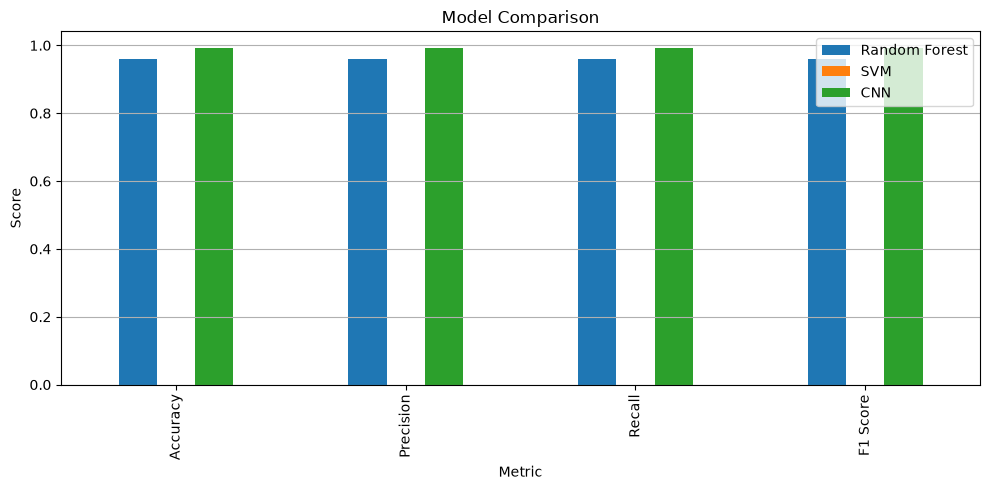

In [27]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(

    kind="bar",

    figsize=(10,5)

)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [28]:
print("="*70)

print("CNN Evaluation Completed Successfully")

print("="*70)

print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision             : {precision:.4f}")
print(f"Recall                : {recall:.4f}")
print(f"F1 Score              : {f1:.4f}")
print(f"Inference Time        : {per_sample*1000:.4f} ms")
print(f"Model Size            : {model_size:.2f} MB")
print(f"Unknown Threshold     : {UNKNOWN_THRESHOLD}")

print("="*70)

CNN Evaluation Completed Successfully
Accuracy              : 0.9916
Precision             : 0.9917
Recall                : 0.9916
F1 Score              : 0.9916
Inference Time        : 3.9943 ms
Model Size            : 5.45 MB
Unknown Threshold     : 0.75
